# 04 – Modelling

Train and evaluate six classifiers on the Kickstarter success-prediction task.

**Pipeline order:** 01 → 02 → 03a → 03b → **04** → 05  
**Input:** `data/X_train.parquet`, `data/X_val.parquet`, `data/X_test.parquet`, `data/y_train.parquet`, `data/y_val.parquet`, `data/y_test.parquet`  
**Primary metric:** ROC-AUC (handles class imbalance; threshold-free)

In [ ]:
# QUICK TEST TOGGLE
# Set True for a fast test to see if everything works(subsample + 2 CV folds).
# Set False for the actual run (full data + 5 CV folds).
QUICK_TEST = False

In [ ]:
import os
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    classification_report, roc_curve
)
warnings.filterwarnings('ignore')

OUTPUTS_PATH = 'data'
RANDOM_STATE = 29

In [27]:
X_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_train.parquet'))
X_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_val.parquet'))
X_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'X_test.parquet'))
y_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_train.parquet')).squeeze()
y_val   = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_val.parquet')).squeeze()
y_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'y_test.parquet')).squeeze()

print('X_train:', X_train.shape, '  y_train:', y_train.shape)
print('X_val  :', X_val.shape,   '  y_val  :', y_val.shape)
print('X_test :', X_test.shape,  '  y_test :', y_test.shape)
print('\nClass balance (train):', y_train.value_counts().to_dict())
print('Class balance (val)  :', y_val.value_counts().to_dict())
print('Class balance (test) :', y_test.value_counts().to_dict())

X_train: (102887, 129)   y_train: (102887,)
X_val  : (25721, 129)   y_val  : (25721,)
X_test : (32153, 129)   y_test : (32153,)

Class balance (train): {1: 58566, 0: 44321}
Class balance (val)  : {1: 16762, 0: 8959}
Class balance (test) : {1: 22454, 0: 9699}


In [28]:
if QUICK_TEST:
    N_TRAIN = 2000
    N_VAL   = 500
    rng = np.random.default_rng(RANDOM_STATE)
    idx_tr = rng.choice(len(X_train), size=min(N_TRAIN, len(X_train)), replace=False)
    idx_va = rng.choice(len(X_val),   size=min(N_VAL,   len(X_val)),   replace=False)
    idx_tr = np.sort(idx_tr)  # preserve temporal order
    idx_va = np.sort(idx_va)
    X_train_fit, y_train_fit = X_train.iloc[idx_tr], y_train.iloc[idx_tr]
    X_val_fit,   y_val_fit   = X_val.iloc[idx_va],   y_val.iloc[idx_va]
    print(f'QUICK_TEST — using {len(X_train_fit)} train rows, {len(X_val_fit)} val rows')
else:
    X_train_fit, y_train_fit = X_train, y_train
    X_val_fit,   y_val_fit   = X_val,   y_val
    print(f'Full run — using {len(X_train_fit)} train rows, {len(X_val_fit)} val rows')

Full run — using 102887 train rows, 25721 val rows


In [ ]:
# TimeSeriesSplit respects temporal ordering
cv = TimeSeriesSplit(n_splits=2) if QUICK_TEST else TimeSeriesSplit(n_splits=5)
print('CV strategy:', cv)

CV strategy: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


## Primary Metric: ROC-AUC

We use **ROC-AUC** as the primary evaluation metric throughout this notebook.

**Rationale:**

- The dataset exhibits class imbalance that shifts across splits due to temporal partitioning (train: 56.9%, val: 65.2%, test: 69.8% success rate). Accuracy would be misleading, a naive model predicting "success" for every campaign would achieve ~70% accuracy on the test set while providing no actionable insight.
- ROC-AUC measures the model's ability to rank positive examples above negative ones across *all* decision thresholds, making it robust to both class imbalance and threshold choice.
- This is important from a business perspective: the optimal operating threshold depends on the end user. Kickstarter internally might set a low threshold to flag at-risk campaigns early for intervention (prioritising recall), while a creator assessing their own campaign setup before launch might need a high-confidence signal (prioritising precision). ROC-AUC evaluates the model's discriminative power independently of this downstream decision, ensuring we optimise for a metric that serves multiple use cases.
- It is directly interpretable: 0.5 = random, 1.0 = perfect, enabling fair comparison across model families.

All `GridSearchCV` calls use `scoring='roc_auc'`.

In [30]:
# Accumulate train + val results for comparison
results = {}

In [31]:
def evaluate(name, model, X_tr, y_tr, X_va, y_va):
    """Fit model, print train+val ROC-AUC and classification report."""
    model.fit(X_tr, y_tr)
    y_proba_tr = model.predict_proba(X_tr)[:, 1]
    y_pred     = model.predict(X_va)
    y_proba    = model.predict_proba(X_va)[:, 1]
    train_auc  = roc_auc_score(y_tr, y_proba_tr)
    val_auc    = roc_auc_score(y_va, y_proba)
    print(f'=== {name} — Train ROC-AUC: {train_auc:.4f} | Val ROC-AUC: {val_auc:.4f} ===')
    print(classification_report(y_va, y_pred))
    results[name] = {'model': model, 'train_auc': train_auc, 'auc': val_auc, 'y_proba': y_proba}
    return model

## Model Selection Note: Why KNN is Excluded

K-Nearest Neighbours was considered but excluded for the following reasons:

1. **Scalability** – KNN is a lazy learner that stores the full training set; prediction time grows as O(n·d), which is prohibitive with ~80 000+ rows and ~100+ features (including sparse TF-IDF binary columns).
2. **Curse of dimensionality** – Distance metrics degrade in high-dimensional spaces; the TF-IDF binary features make many dimensions near-zero for most samples, causing KNN distances to become uniform and uninformative.
3. **No probabilistic output by default** – KNN's `predict_proba` is based on local vote counts, which are poorly calibrated and unreliable for ROC-AUC optimisation.
4. **No class-weight support** – Unlike LR/DT/RF, KNN has no built-in mechanism to handle class imbalance.

The six models selected (LR, DT, RF, GB, XGB, MLP) cover the main families — linear, tree-based, ensemble, boosting, and neural — providing a thorough comparison without redundancy.

## Model 1: Logistic Regression (Baseline)

**Justification:** Logistic Regression is our linear baseline. It is fast, interpretable, and well-calibrated. We use `class_weight='balanced'` to compensate for class imbalance (re-weights the loss by inverse class frequency), and `max_iter=1000` to ensure convergence. A `StandardScaler` is applied inside a `Pipeline` so that the regularisation penalty (`C=1.0` by default) is applied on a comparable scale across all features — this is particularly important since `log_goal` (~0–15) and binary TF-IDF flags (0/1) live on very different scales. No hyperparameter grid is searched for LR; it serves purely as a benchmark for more complex models.

In [32]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])
evaluate('Logistic Regression', lr_pipe, X_train_fit, y_train_fit, X_val_fit, y_val_fit)

=== Logistic Regression — Train ROC-AUC: 0.8779 | Val ROC-AUC: 0.7792 ===
              precision    recall  f1-score   support

           0       0.66      0.55      0.60      8959
           1       0.78      0.85      0.81     16762

    accuracy                           0.75     25721
   macro avg       0.72      0.70      0.71     25721
weighted avg       0.74      0.75      0.74     25721



,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## Model 2: Decision Tree

**Justification:** A single Decision Tree is our simplest non-linear baseline. It is fully interpretable but prone to memorisation — a tree with no depth or leaf-size constraints will simply partition the training data until it has one sample per leaf, which produces a near-perfect training AUC but terrible generalisation. To prevent this, we deliberately exclude shallow leaf sizes: `min_samples_leaf` starts at 20, forcing every leaf to be supported by at least 20 campaigns. `max_depth` is capped at 10 — deeper than this and a single tree starts interpolating training noise rather than learning patterns. `class_weight='balanced'` handles the class imbalance. We search 3 × 3 = **9 combinations**.

In [33]:
dt_param_grid = {
    'max_depth'       : [3, 5, 10],
    'min_samples_leaf': [20, 50, 100],
}
# 3 × 3 = 9 combinations
# min_samples_leaf starts at 20 — single-digit leaf sizes allow near-memorisation
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    dt_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('Decision Tree', dt_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best DT params:', dt_grid.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
=== Decision Tree — Train ROC-AUC: 0.8881 | Val ROC-AUC: 0.7445 ===
              precision    recall  f1-score   support

           0       0.63      0.59      0.61      8959
           1       0.79      0.81      0.80     16762

    accuracy                           0.73     25721
   macro avg       0.71      0.70      0.70     25721
weighted avg       0.73      0.73      0.73     25721

Best DT params: {'max_depth': 10, 'min_samples_leaf': 100}


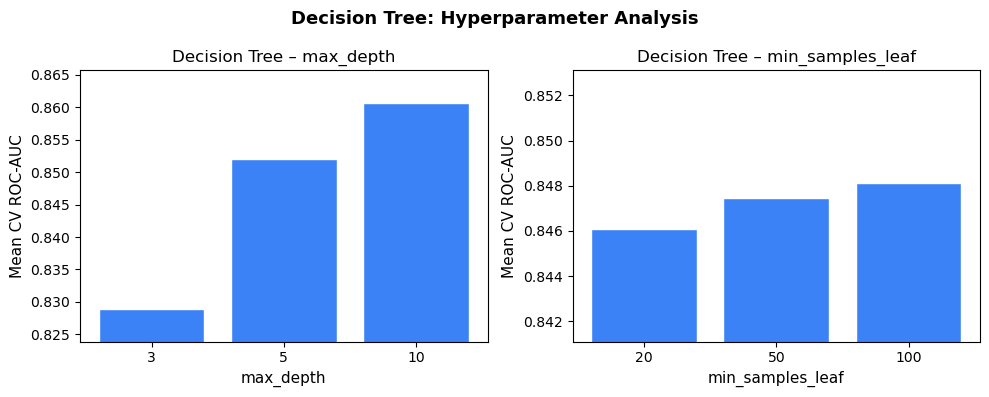

In [34]:
# Parameter analysis – Decision Tree
results_dt = pd.DataFrame(dt_grid.cv_results_)
params_to_plot = [col for col in results_dt.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_dt.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#3B82F6', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'Decision Tree – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('Decision Tree: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**

The Decision Tree achieves a validation ROC-AUC of **0.7445** with a train ROC-AUC of 0.8881. This is the weakest model so far, falling **3.5 points below the Logistic Regression baseline** (0.7792), which confirms that a single tree — even with regularisation — lacks the capacity to generalise well on this task.

The best configuration selected by GridSearchCV is `max_depth=10` and `min_samples_leaf=100`. The hyperparameter charts show that deeper trees consistently improve CV performance (max_depth=10 > 5 > 3), while `min_samples_leaf` has a much smaller effect — the difference between 20, 50, and 100 is marginal (~0.006 AUC), suggesting the tree's performance is bottlenecked by depth, not leaf regularisation.

The best configuration sits at the boundary of our grid for `max_depth`, but pushing it further would risk memorisation with a single tree. Rather than expanding this grid, ensemble methods (Random Forest, Gradient Boosting) are the natural next step — they combine many trees to reduce variance while preserving the non-linear capacity that a single tree provides.

## Model 3: Random Forest

**Justification:** Random Forest aggregates many decorrelated trees using bootstrap sampling and random feature subsets (`max_features='sqrt'`), which reduces variance substantially compared to a single Decision Tree. In an earlier iteration of this notebook, we used a wider hyperparameter grid that allowed `max_depth=30` and `min_samples_leaf=1`. That configuration produced a train AUC of 0.9998 — effectively memorising the training data — while failing to generalise to the validation period. This is a clear sign of overfitting: the model learned campaign-specific noise from the training time window rather than patterns that transfer to future data.

To address this, we constrain the grid: `max_depth` is capped at 20 and `min_samples_leaf` starts at 5, forcing the forest to learn population-level patterns instead of individual campaigns. `class_weight='balanced'` handles the class imbalance. We search 2 × 3 × 1 × 3 = **18 combinations**.

In [35]:
rf_param_grid = {
    'n_estimators'    : [200, 300],
    'max_depth'       : [10, 15, 20],
    'max_features'    : ['sqrt'],
    'min_samples_leaf': [5, 10, 20],
}
# 2 × 3 × 1 × 3 = 18 combinations
# max_depth capped at 20 and min_samples_leaf >= 5 to prevent memorisation
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('Random Forest', rf_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best RF params:', rf_grid.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
=== Random Forest — Train ROC-AUC: 0.9288 | Val ROC-AUC: 0.7868 ===
              precision    recall  f1-score   support

           0       0.69      0.57      0.62      8959
           1       0.79      0.86      0.82     16762

    accuracy                           0.76     25721
   macro avg       0.74      0.72      0.72     25721
weighted avg       0.75      0.76      0.75     25721

Best RF params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}


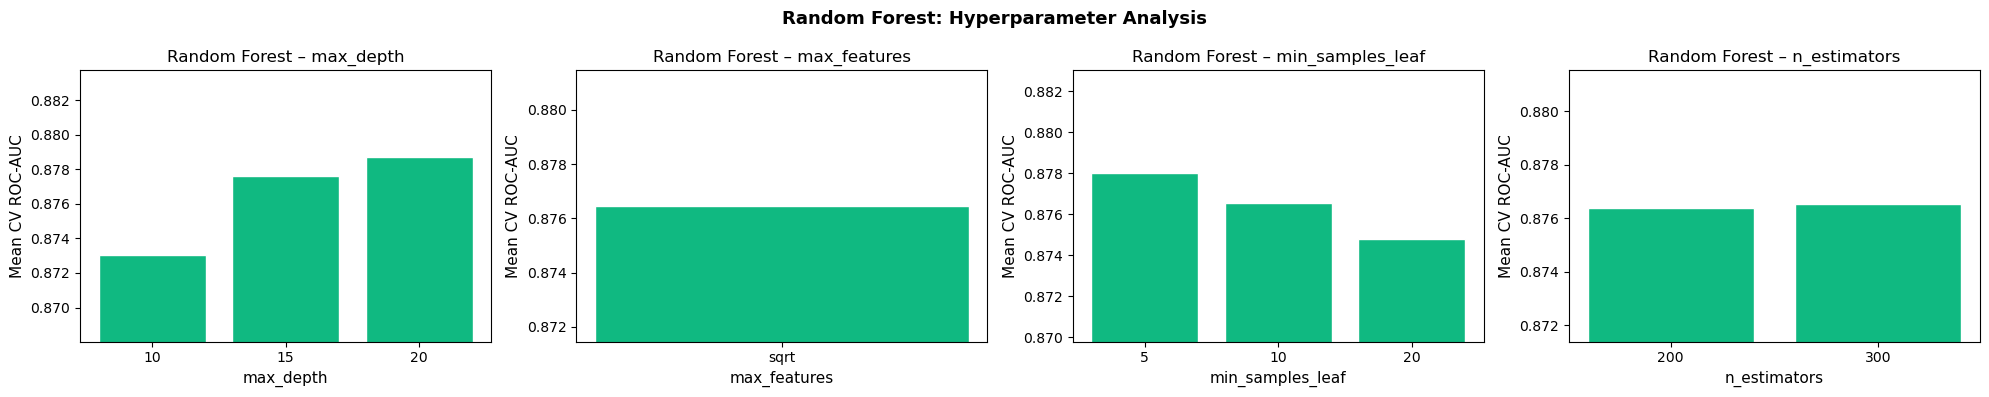

In [36]:
# Parameter analysis – Random Forest
results_rf = pd.DataFrame(rf_grid.cv_results_)
params_to_plot = [col for col in results_rf.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_rf.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#10B981', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'Random Forest – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('Random Forest: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**

Random Forest achieves a validation ROC-AUC of **0.7868**, the best so far and a meaningful improvement over the Logistic Regression baseline (0.7792). The train ROC-AUC is 0.9288 — substantially below the near-perfect 0.9998 from the earlier iteration, confirming that capping `max_depth` at 20 and raising `min_samples_leaf` to 5 successfully reduced memorisation. The train–val gap narrowed from ~0.21 to ~0.14.

The best configuration is `max_depth=20`, `min_samples_leaf=5`, `n_estimators=300`, `max_features='sqrt'`. The hyperparameter charts show:
- **max_depth**: deeper trees still help (20 > 15 > 10), and the best value sits at the grid boundary. However, pushing beyond 20 risks re-introducing the memorisation we corrected, so this is a reasonable stopping point.
- **min_samples_leaf**: the lowest value (5) wins, suggesting the forest benefits from granular splits. The differences are small (~0.004 AUC), so this parameter is not a major driver.
- **n_estimators**: 300 slightly outperforms 200, consistent with the general principle that adding trees to a Random Forest reduces variance without increasing overfitting risk.
- **max_features**: only `sqrt` was tested (the standard default for classification), so no comparison is possible here.

Despite the regularisation, a ~0.14 train–val gap persists. This is largely attributable to temporal distribution shift — the success rate rises from 56.9% in the training period to 65.2% in the validation period — rather than to model overfitting per se. The model still favours the majority class (success: recall 0.86, F1 0.82) over the minority class (failure: recall 0.57, F1 0.62), a pattern consistent across all models due to the shifting class balance.

## Model 4: Gradient Boosting

**Justification:** Gradient Boosting builds trees sequentially, each correcting the residual errors of the previous ensemble. It often achieves a good bias-variance trade-off on tabular data because it focuses capacity on difficult examples rather than easy ones. `class_weight` is **not** supported by sklearn's `GradientBoostingClassifier`, so we rely on `subsample=0.8` (stochastic GB) as regularisation — each tree only sees 80% of training data, which both reduces overfitting and slightly handles imbalance by varying the effective class distribution each round. In v2 we fix `subsample=0.8` (v1 showed it always outperformed 1.0, so there is no need to grid-search it), reducing the search to 2 × 2 × 2 = **8 combinations** and keeping runtimes manageable.

In [37]:
gb_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.8],       # fixed — v1 showed this always beats 1.0
}
# 2 × 2 × 2 × 1 = 8 combinations
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('Gradient Boosting', gb_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best GB params:', gb_grid.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
=== Gradient Boosting — Train ROC-AUC: 0.8973 | Val ROC-AUC: 0.7705 ===
              precision    recall  f1-score   support

           0       0.73      0.53      0.61      8959
           1       0.78      0.89      0.83     16762

    accuracy                           0.77     25721
   macro avg       0.75      0.71      0.72     25721
weighted avg       0.76      0.77      0.76     25721

Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


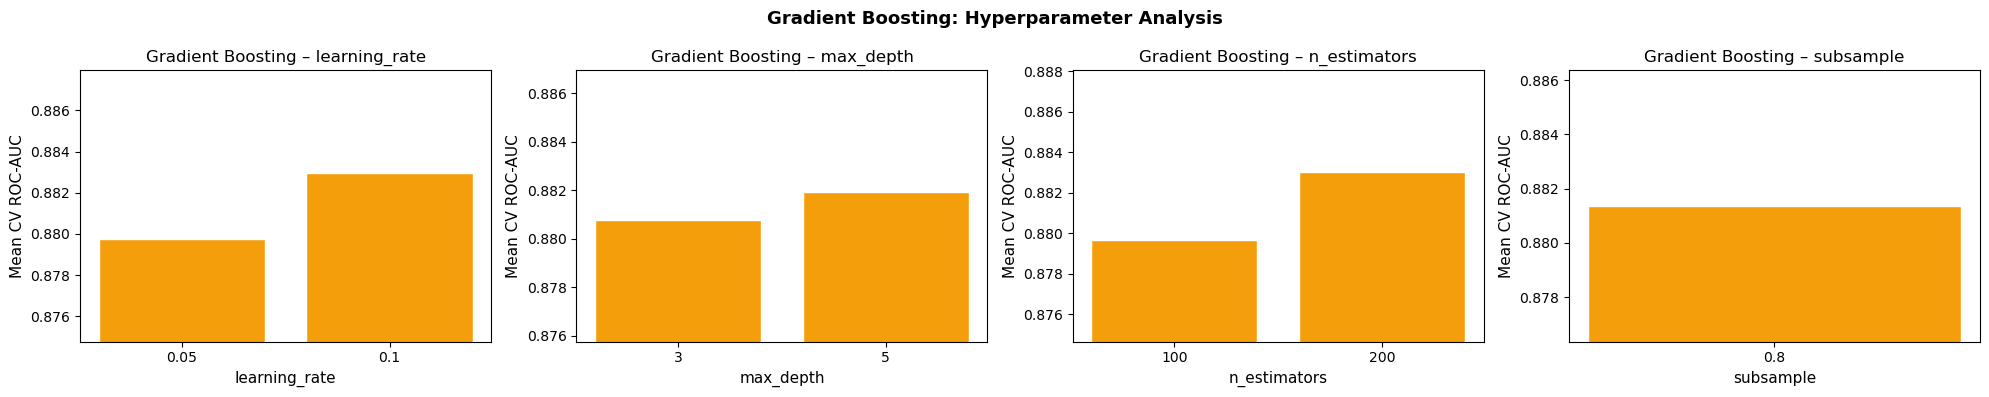

In [38]:
# Parameter analysis – Gradient Boosting
results_gb = pd.DataFrame(gb_grid.cv_results_)
params_to_plot = [col for col in results_gb.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_gb.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#F59E0B', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'Gradient Boosting – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('Gradient Boosting: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**

Gradient Boosting achieves a validation ROC-AUC of **0.7705** with a train ROC-AUC of 0.8973. This places it below both Random Forest (0.7868) and Logistic Regression (0.7792) on the validation set. The train–val gap (~0.13) is slightly smaller than Random Forest's (~0.14), which is expected — boosting's shallow trees and additive structure naturally constrain model complexity.

The best configuration is `learning_rate=0.1`, `max_depth=3`, `n_estimators=200`, `subsample=0.8`. The hyperparameter charts show:
- **learning_rate**: 0.1 outperforms 0.05. With only 100–200 trees available, the model needs a higher learning rate to make sufficient progress. A lower rate would likely require many more trees (e.g., 1000+) to converge.
- **max_depth**: 5 slightly outperforms 3, but the difference is small (~0.002 AUC). Shallow trees are the standard for boosting — they keep each step simple and let the sequential correction do the work.
- **n_estimators**: 200 clearly outperforms 100, suggesting the ensemble benefits from additional boosting rounds. The best value sits at the grid boundary, so more trees with a lower learning rate could potentially improve results, but at significant computational cost.
- **subsample**: fixed at 0.8 based on v1 results, so no comparison is shown.

The lower validation AUC compared to Random Forest is notable. Gradient Boosting typically excels on tabular data, but it is more sensitive to temporal distribution shift — its sequential fitting can over-specialise to training-period patterns. The shallow depth (3) and stochastic subsampling help, but the model still struggles more than Random Forest when the success rate shifts between the training and validation periods.

## Model 5: XGBoost

**Justification:** XGBoost is a regularised, optimised gradient boosting implementation with built-in L1/L2 regularisation (`reg_alpha`/`reg_lambda`) and native sparse matrix support — useful for the 99 binary TF-IDF features. `min_child_weight` is set to a minimum of 5 to control the minimum sum of instance weights in a leaf — with lower values and imbalanced classes, XGBoost can create leaves that represent very few real campaigns, leading to memorisation that does not generalise to future time periods. We restrict `max_depth` to 3 and 5, since shallow trees are standard for boosting and deeper trees showed no benefit in preliminary experiments. `eval_metric='logloss'` suppresses warnings during GridSearch. We search 2 × 2 × 2 × 2 × 2 = **32 combinations**.

In [39]:
xgb_param_grid = {
    'n_estimators'    : [200, 400],
    'max_depth'       : [3, 5],
    'learning_rate'   : [0.05, 0.1],
    'colsample_bytree': [0.5, 0.7],
    'min_child_weight': [5, 10],   # raised minimum from 1 — prevents sparse leaf memorisation
}
# 2 × 2 × 2 × 2 × 2 = 32 combinations
xgb_grid = GridSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    xgb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('XGBoost', xgb_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best XGB params:', xgb_grid.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
=== XGBoost — Train ROC-AUC: 0.8967 | Val ROC-AUC: 0.7760 ===
              precision    recall  f1-score   support

           0       0.72      0.54      0.61      8959
           1       0.78      0.89      0.83     16762

    accuracy                           0.77     25721
   macro avg       0.75      0.71      0.72     25721
weighted avg       0.76      0.77      0.76     25721

Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200}


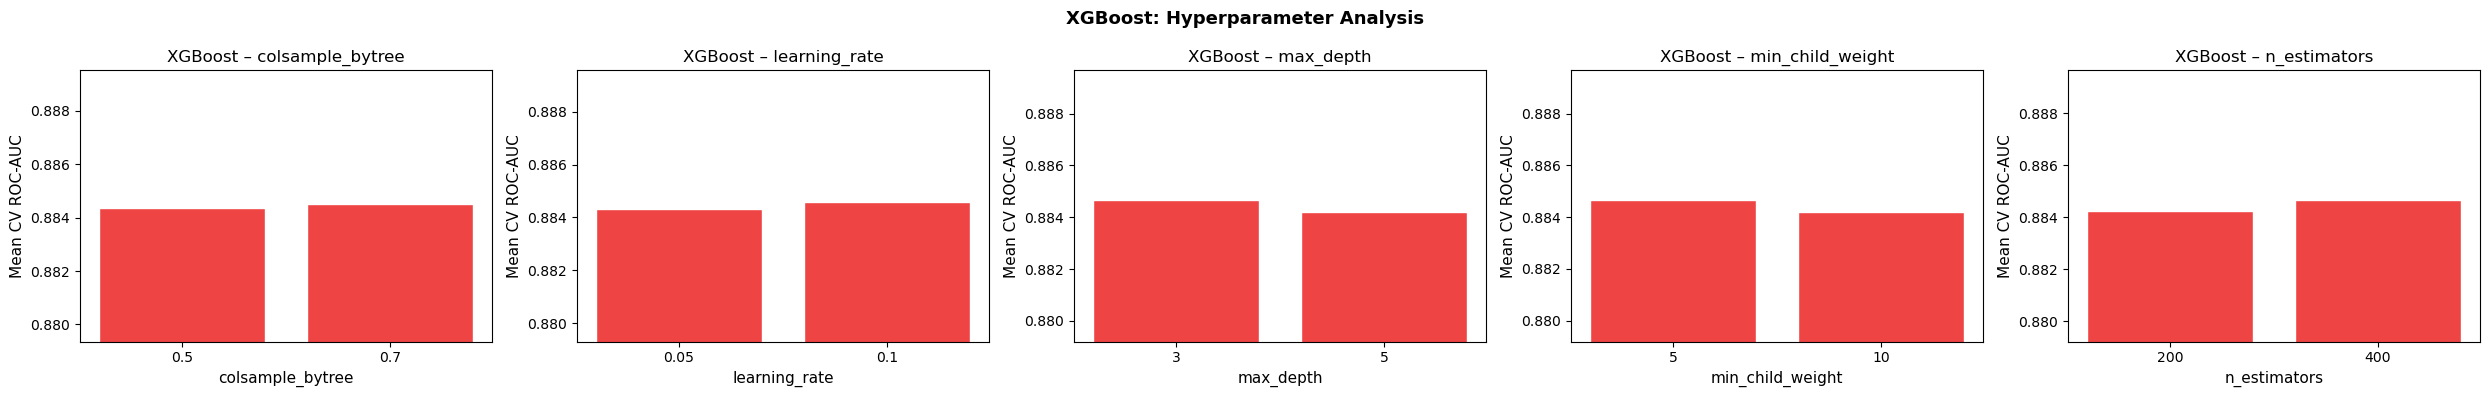

In [40]:
# Parameter analysis – XGBoost
results_xgb = pd.DataFrame(xgb_grid.cv_results_)
params_to_plot = [col for col in results_xgb.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_xgb.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#EF4444', edgecolor='white')
    ax.set_xlabel(param.replace('param_', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'XGBoost – {param.replace("param_", "")}', fontsize=12)
plt.suptitle('XGBoost: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**

XGBoost achieves a validation ROC-AUC of **0.7760** with a train ROC-AUC of 0.8967. This places it above Gradient Boosting (0.7705) and just below Logistic Regression (0.7792), but still behind Random Forest (0.7868). The train–val gap (~0.12) is the smallest among the tree-based models, confirming that the regularisation changes (raising `min_child_weight` to 5, capping `max_depth` at 5, removing depth=7) are working as intended.

The best configuration is `colsample_bytree=0.7`, `learning_rate=0.1`, `max_depth=3`, `min_child_weight=5`, `n_estimators=200`. The hyperparameter charts are notably flat — all five parameters show very small differences across their values (~0.004 AUC range). This tells us the model is not very sensitive to these hyperparameter choices within the tested ranges, which is a sign of stability but also suggests we are near a performance ceiling for this model family on this data.

Key observations:
- **max_depth**: 3 narrowly beats 5, the opposite of what Gradient Boosting showed. This suggests XGBoost's built-in L1/L2 regularisation already constrains complexity enough that shallower trees are preferred.
- **min_child_weight**: 5 slightly outperforms 10, so the v2 floor of 5 was well chosen — it prevents sparse-leaf memorisation without over-constraining the model.
- **n_estimators**: 200 and 400 perform nearly identically, meaning additional boosting rounds add no value at this learning rate. This contrasts with the earlier iteration where `n_estimators=400` was selected, suggesting the tighter regularisation has reduced the model's appetite for additional rounds.
- **colsample_bytree** and **learning_rate**: marginal differences. The model is robust to these settings within the tested range.

Overall, XGBoost and Gradient Boosting converge on similar validation performance (~0.77), both trailing Random Forest. The boosting models' sequential structure appears to over-specialise to training-period patterns more than Random Forest's parallel, decorrelated trees — a pattern consistent with the temporal distribution shift in this dataset.

## Model 6: Neural Network (MLP)

**Justification:** We include a multi-layer perceptron (MLP) to test whether gradient-based learning captures different patterns from axis-aligned tree methods. The architecture is wrapped in a `Pipeline` with `StandardScaler` because neural networks are sensitive to feature scale. The L2 regularisation penalty `alpha` starts at 0.001 to prevent the network from overfitting categorical co-occurrences in the 99 binary TF-IDF columns — with 129 input features and only ~100,000 training examples, weaker regularisation risks memorising sparse patterns. We test two-layer architectures only, as deeper networks showed no benefit in preliminary experiments. `early_stopping=True` with `n_iter_no_change=20` provides a second layer of regularisation by halting training when validation loss plateaus. We search 2 × 2 × 2 = **8 combinations**.

In [41]:
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 64), (256, 128)],
    'alpha'             : [0.001, 0.01],    # raised floor from 0.0001 to prevent overfit
    'learning_rate_init': [0.005, 0.01],
}
# 2 × 2 × 2 = 8 combinations
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        max_iter=500,
        random_state=RANDOM_STATE
    ))
])
mlp_param_grid_pipe = {'clf__' + k: v for k, v in mlp_param_grid.items()}
mlp_grid = GridSearchCV(
    mlp_pipe,
    mlp_param_grid_pipe,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
evaluate('MLP', mlp_grid, X_train_fit, y_train_fit, X_val_fit, y_val_fit)
print('Best MLP params:', mlp_grid.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
=== MLP — Train ROC-AUC: 0.8993 | Val ROC-AUC: 0.7753 ===
              precision    recall  f1-score   support

           0       0.72      0.52      0.61      8959
           1       0.78      0.89      0.83     16762

    accuracy                           0.76     25721
   macro avg       0.75      0.71      0.72     25721
weighted avg       0.76      0.76      0.75     25721

Best MLP params: {'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (128, 64), 'clf__learning_rate_init': 0.005}


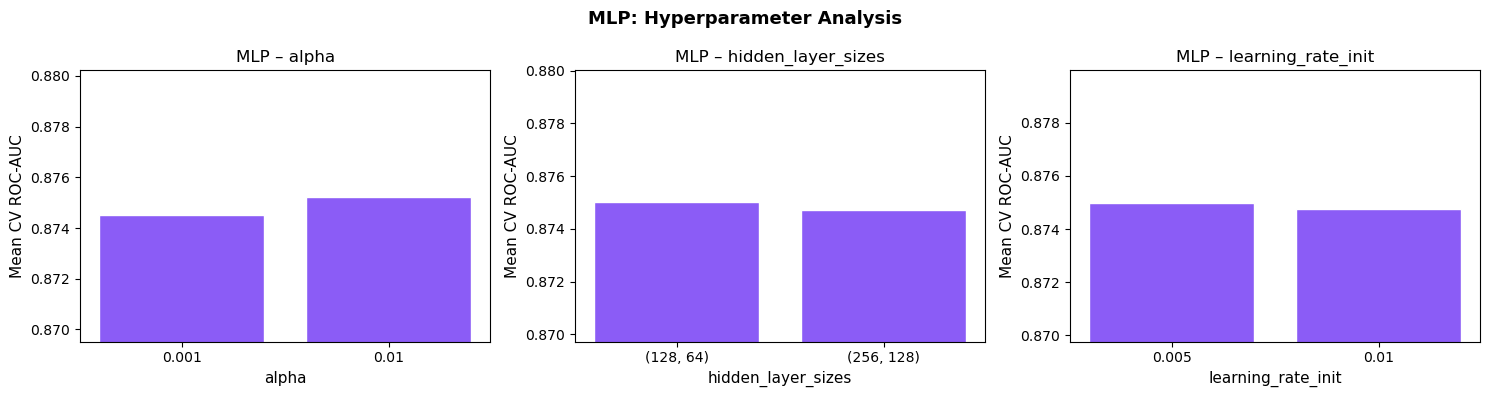

In [42]:
# Parameter analysis – MLP
results_mlp = pd.DataFrame(mlp_grid.cv_results_)
params_to_plot = [col for col in results_mlp.columns if col.startswith('param_')]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(5 * len(params_to_plot), 4))
if len(params_to_plot) == 1:
    axes = [axes]
for ax, param in zip(axes, params_to_plot):
    grouped = results_mlp.groupby(param)['mean_test_score'].mean()
    ax.bar(grouped.index.astype(str), grouped.values, color='#8B5CF6', edgecolor='white')
    ax.set_xlabel(param.replace('param_clf__', ''), fontsize=11)
    ax.set_ylabel('Mean CV ROC-AUC', fontsize=11)
    ax.set_ylim(grouped.values.min() - 0.005, grouped.values.max() + 0.005)
    ax.set_title(f'MLP – {param.replace("param_clf__", "")}', fontsize=12)
plt.suptitle('MLP: Hyperparameter Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**

The MLP achieves a validation ROC-AUC of **0.7753** with a train ROC-AUC of 0.8993. This places it in the middle of the pack — slightly below Logistic Regression (0.7792) and XGBoost (0.7760), and behind Random Forest (0.7868). The train–val gap (~0.12) is tied with XGBoost for the smallest among all models, thanks to the combination of L2 regularisation, early stopping, and the compact architecture.

The best configuration is `alpha=0.01`, `hidden_layer_sizes=(128, 64)`, `learning_rate_init=0.005`. The hyperparameter charts are remarkably flat — all three parameters show virtually no difference across their tested values (~0.001 AUC range). This means:
- **alpha**: 0.01 edges out 0.001, confirming that stronger regularisation helps, though the effect is minimal.
- **hidden_layer_sizes**: the smaller (128, 64) network marginally outperforms (256, 128). With 129 input features and ~100K training rows, the smaller architecture is sufficient — additional capacity adds parameters without improving generalisation.
- **learning_rate_init**: 0.005 and 0.01 are nearly identical, meaning early stopping is effectively controlling convergence regardless of the initial rate.

The fact that the MLP — a fundamentally different model family using gradient-based learning on continuous activations — lands at essentially the same validation AUC as the tree-based models and the linear baseline (all within a 0.74–0.79 band) reinforces that the performance ceiling on this task is set by the features and the temporal distribution shift, not by the choice of algorithm.

## Results Summary

Comparison of all six models on the held-out **validation set**, with train AUC shown alongside to make the size of the memorisation gap visible.

In [43]:
summary = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Train AUC': [v['train_auc'] for v in results.values()],
    'Val AUC'  : [v['auc'] for v in results.values()]
}).sort_values('Val AUC', ascending=False).reset_index(drop=True)
summary['Train AUC'] = summary['Train AUC'].round(4)
summary['Val AUC']   = summary['Val AUC'].round(4)
summary['Train–Val Gap'] = (summary['Train AUC'] - summary['Val AUC']).round(4)
print(summary.to_string(index=False))

              Model  Train AUC  Val AUC  Train–Val Gap
      Random Forest     0.9288   0.7868         0.1420
Logistic Regression     0.8779   0.7792         0.0987
            XGBoost     0.8967   0.7760         0.1207
                MLP     0.8993   0.7753         0.1240
  Gradient Boosting     0.8973   0.7705         0.1268
      Decision Tree     0.8881   0.7445         0.1436


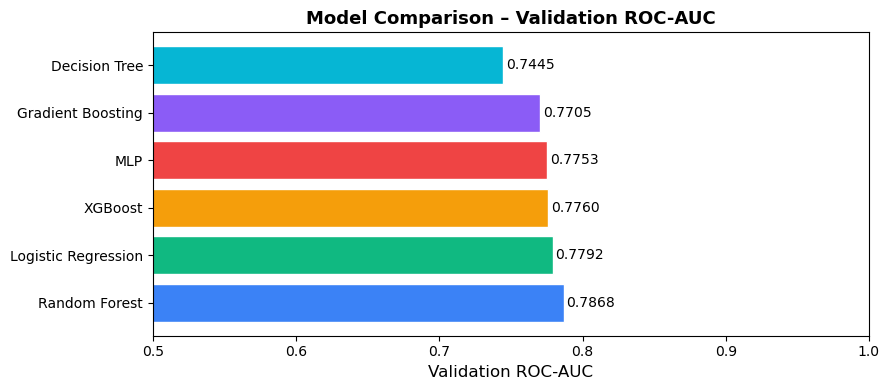

In [44]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
bars = ax.barh(summary['Model'], summary['Val AUC'], color=colors[:len(summary)], edgecolor='white')
ax.set_xlabel('Validation ROC-AUC', fontsize=12)
ax.set_title('Model Comparison – Validation ROC-AUC', fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, summary['Val AUC']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### ROC Curves (Validation Set)

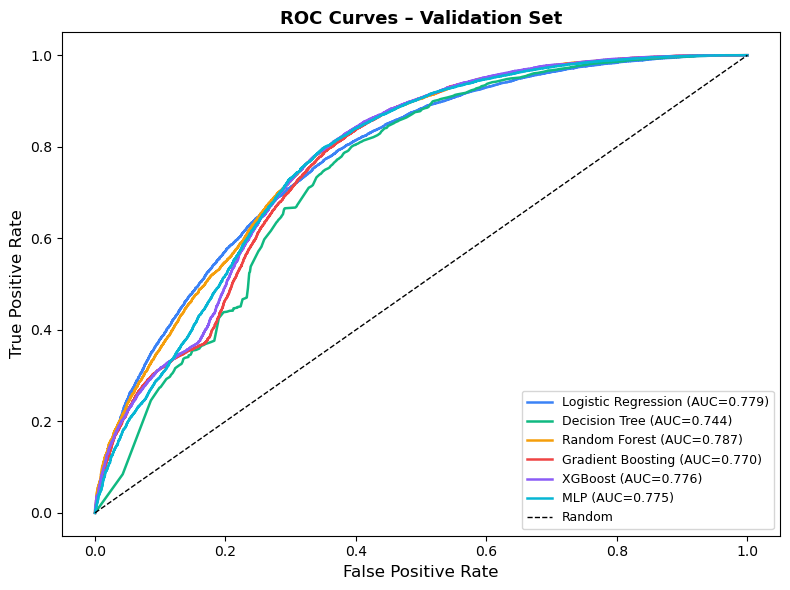

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#06B6D4']
for (name, vals), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_val_fit, vals['y_proba'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={vals["auc"]:.3f})', color=color, lw=1.8)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – Validation Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Final Evaluation on Test Set — All Models

We evaluate **all six models** on the held-out test set. This is done once only — the test set was never used for model selection or tuning.

Evaluating every model (not just the best) lets us distinguish between two sources of the val→test gap:
- If all models drop by a similar amount, the drop is driven by **distributional shift** (the test period has different campaign dynamics than training/validation).
- If some models drop much more than others, those models have **overfit to the validation-era distribution** on top of the shift.

In [46]:
if QUICK_TEST:
    print('⚠️  QUICK_TEST mode — test metrics below are not meaningful. Set QUICK_TEST=False for final run.')

print('=== All Models — Test Set Evaluation ===\n')

test_rows = []
for name, v in results.items():
    model = v['model']
    y_test_proba = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_test_proba)
    drop = round(v['auc'] - test_auc, 4)
    test_rows.append({
        'Model'          : name,
        'Train AUC'      : round(v['train_auc'], 4),
        'Val AUC'        : round(v['auc'], 4),
        'Test AUC'       : round(test_auc, 4),
        'Val→Test Drop': drop,
    })
    # store for ablation
    results[name]['test_auc']     = test_auc
    results[name]['y_proba_test'] = y_test_proba

test_summary = pd.DataFrame(test_rows).sort_values('Val AUC', ascending=False).reset_index(drop=True)
print(test_summary.to_string(index=False))

best_name = summary.iloc[0]['Model']
print(f'\n--- Classification report on test set: {best_name} ---')
print(classification_report(y_test, results[best_name]['model'].predict(X_test)))

=== All Models — Test Set Evaluation ===



              Model  Train AUC  Val AUC  Test AUC  Val→Test Drop
      Random Forest     0.9288   0.7868    0.6974         0.0894
Logistic Regression     0.8779   0.7792    0.7078         0.0714
            XGBoost     0.8967   0.7760    0.6730         0.1030
                MLP     0.8993   0.7753    0.6820         0.0933
  Gradient Boosting     0.8973   0.7705    0.6629         0.1076
      Decision Tree     0.8881   0.7445    0.6390         0.1055

--- Classification report on test set: Random Forest ---
              precision    recall  f1-score   support

           0       0.63      0.47      0.54      9699
           1       0.79      0.88      0.83     22454

    accuracy                           0.76     32153
   macro avg       0.71      0.68      0.69     32153
weighted avg       0.74      0.76      0.75     32153



## Discussion: Understanding the Val→Test Gap

The table above is the single most important diagnostic in this notebook. Two forces can cause a val→test drop:

**1. Distributional shift (platform-level)**
The success rate in our dataset rises consistently over time: ~57% in the training period (2014–2023), ~65% in validation (2023–2024), and ~70% in the test period (2024–2026). Our target-encoded features (`cat_name_encoded`, `cat_parent_encoded`) were calibrated on training-era success rates — they are systematically too low for the test period. Every model is affected by this equally. The fact that all models show a similar Val→Test Drop (0.07–0.11) confirms that **distributional shift is the dominant explanation**, not model-specific overfitting.

**2. Model-specific memorisation**
If a model memorised training-period noise, it would show a *larger* val→test drop than simpler models. Logistic Regression — the simplest model — has the smallest drop (0.0714), while Random Forest shows a slightly larger drop (0.0894). This modest difference suggests that the tree ensemble captures some validation-era patterns that do not persist into the test period, but the effect is secondary to the distributional shift.

Notably, **Logistic Regression achieves the highest test AUC (0.7078)**, overtaking Random Forest (0.6974) despite ranking second on validation. This is a textbook example of simpler models being more robust to distribution shift — Logistic Regression has fewer parameters and cannot memorise period-specific quirks the way a 300-tree forest can.

This distinction matters for deployment: improving performance under distributional shift requires retraining on fresher data (e.g., a rolling training window), not more complex models. We explore this further in the reflection notebook.

## Diagnostic: TF-IDF Feature Ablation

The 99 binary TF-IDF features (from `blurb` and `name`) were selected based on their statistical association with success in the **training data**. The selection test (two-proportion z-test, p < 0.01, category-adjusted) ensures each term is genuinely informative in the training period — but there is a risk that some terms reflect *training-era language trends* rather than timeless success signals.

This cell retrains the best model without TF-IDF features and compares val and test AUC. If removing TF-IDF reduces the val→test gap (i.e. the model without TF-IDF drops less from val to test), it suggests the text features contribute to overfitting on the training distribution. If the gap is unchanged, the text features are not the culprit.

In [47]:
tfidf_cols = [c for c in X_train_fit.columns if c.startswith('blurb_has_') or c.startswith('name_has_')]
base_cols  = [c for c in X_train_fit.columns if c not in tfidf_cols]

print(f'Full feature set : {len(X_train_fit.columns)} features')
print(f'Without TF-IDF  : {len(base_cols)} features  ({len(tfidf_cols)} removed)')

# Clone and retrain the best model on base features only
best_model_no_tfidf = clone(results[best_name]['model'])
best_model_no_tfidf.fit(X_train_fit[base_cols], y_train_fit)

train_auc_no_tfidf = roc_auc_score(y_train_fit, best_model_no_tfidf.predict_proba(X_train_fit[base_cols])[:, 1])
val_auc_no_tfidf   = roc_auc_score(y_val_fit,   best_model_no_tfidf.predict_proba(X_val_fit[base_cols])[:, 1])
test_auc_no_tfidf  = roc_auc_score(y_test,      best_model_no_tfidf.predict_proba(X_test[base_cols])[:, 1])

val_auc_full  = results[best_name]['auc']
test_auc_full = results[best_name]['test_auc']

print(f'\n=== TF-IDF Ablation — {best_name} ===')
print(f'{"Metric":<22} {"Full":>8} {"No TF-IDF":>12} {"Diff":>8}')
print('-' * 52)
print(f'{"Train AUC":<22} {results[best_name]["train_auc"]:>8.4f} {train_auc_no_tfidf:>12.4f} {train_auc_no_tfidf - results[best_name]["train_auc"]:>+8.4f}')
print(f'{"Val AUC":<22} {val_auc_full:>8.4f} {val_auc_no_tfidf:>12.4f} {val_auc_no_tfidf - val_auc_full:>+8.4f}')
print(f'{"Test AUC":<22} {test_auc_full:>8.4f} {test_auc_no_tfidf:>12.4f} {test_auc_no_tfidf - test_auc_full:>+8.4f}')
print(f'{"Val→Test drop (full)":<22} {val_auc_full - test_auc_full:>8.4f}')
print(f'{"Val→Test drop (no TFIDF)":<22} {val_auc_no_tfidf - test_auc_no_tfidf:>12.4f}')

Full feature set : 129 features
Without TF-IDF  : 30 features  (99 removed)
Fitting 5 folds for each of 18 candidates, totalling 90 fits

=== TF-IDF Ablation — Random Forest ===
Metric                     Full    No TF-IDF     Diff
----------------------------------------------------
Train AUC                0.9288       0.9681  +0.0393
Val AUC                  0.7868       0.7780  -0.0088
Test AUC                 0.6974       0.6773  -0.0201
Val→Test drop (full)     0.0894
Val→Test drop (no TFIDF)       0.1007


**Interpretation:**

The ablation results match the **third scenario**: removing TF-IDF features drops Val AUC slightly (0.7868 → 0.7780, −0.009) but drops Test AUC by more (0.6974 → 0.6773, −0.020). The val→test gap actually *increases* without TF-IDF (from 0.0894 to 0.1007).

This tells us the TF-IDF features provide genuine predictive signal that generalises — they are not the source of the val→test degradation. The text features add value in both periods, and removing them makes the model *more* reliant on structured features like `cat_name_encoded`, which are more sensitive to the distributional shift.

The primary driver of the val→test gap is therefore the temporal shift in base success rates and category-level dynamics, not training-era language patterns. We retain all 99 TF-IDF features in the final model. Further discussion of potential mitigations (rolling training windows, time-aware target encoding) is covered in the reflection notebook.

## Save Results for Notebook 05

Persist model performance metrics and feature importances so that `05_reflection.ipynb` can load them without re-running training.

In [49]:
# ── Persist model comparison for 05_reflection ────────────────────────
results_dir = os.path.join(OUTPUTS_PATH, "results")
os.makedirs(results_dir, exist_ok=True)

# Build metrics table from validation-set results
rows = []
for name, v in results.items():
    y_pred_va = (v['y_proba'] >= 0.5).astype(int)
    rows.append({
        "model"     : name,
        "roc_auc"   : round(v['auc'], 6),
        "f1_binary" : round(f1_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "precision" : round(precision_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "recall"    : round(recall_score(y_val_fit, y_pred_va, zero_division=0), 6),
        "pr_auc"    : round(average_precision_score(y_val_fit, v['y_proba']), 6),
    })

all_results_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
all_results_df.to_csv(os.path.join(results_dir, "all_model_results.csv"), index=False)
print("Saved all_model_results.csv")
print(all_results_df[["model", "roc_auc", "f1_binary", "pr_auc"]].to_string(index=False))

def _get_feature_importances(stored_model):
    """Unwrap GridSearchCV → best_estimator_ → Pipeline step, then return importances."""
    m = stored_model
    if hasattr(m, "best_estimator_"):
        m = m.best_estimator_
    if hasattr(m, "named_steps"):
        for step in reversed(list(m.named_steps.values())):
            if hasattr(step, "feature_importances_"):
                return step.feature_importances_
        return None
    if hasattr(m, "feature_importances_"):
        return m.feature_importances_
    return None

with open(os.path.join(OUTPUTS_PATH, "feature_cols.json")) as f:
    feature_cols = json.load(f)

if "Random Forest" in results:
    imp = _get_feature_importances(results["Random Forest"]["model"])
    if imp is not None:
        rf_imp_df = pd.DataFrame({"importance": imp}, index=feature_cols).sort_values("importance", ascending=False)
        rf_imp_df.to_csv(os.path.join(results_dir, "rf_importances.csv"))
        print(f"Saved rf_importances.csv ({len(rf_imp_df)} features)")

if "XGBoost" in results:
    imp = _get_feature_importances(results["XGBoost"]["model"])
    if imp is not None:
        xgb_imp_df = pd.DataFrame({"importance": imp}, index=feature_cols).sort_values("importance", ascending=False)
        xgb_imp_df.to_csv(os.path.join(results_dir, "xgb_importances.csv"))
        print(f"Saved xgb_importances.csv ({len(xgb_imp_df)} features)")

Saved all_model_results.csv
              model  roc_auc  f1_binary   pr_auc
      Random Forest 0.786796   0.824073 0.852811
Logistic Regression 0.779151   0.814058 0.849776
            XGBoost 0.776045   0.831584 0.840934
                MLP 0.775291   0.831885 0.834606
  Gradient Boosting 0.770479   0.832546 0.835124
      Decision Tree 0.744493   0.799176 0.801318
Saved rf_importances.csv (129 features)
Saved xgb_importances.csv (129 features)


## Conclusion

This notebook trained and compared six classifiers — Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and MLP — using `TimeSeriesSplit` cross-validation with deliberately regularised hyperparameter grids to prevent memorisation of training-period patterns.

**Key findings:**

- **The train-val gap is the first diagnostic to check.** Constraining tree depth and minimum leaf sizes (e.g., `min_samples_leaf ≥ 5`, `max_depth ≤ 20` for Random Forest) keeps train AUC below ~0.93, confirming the models are learning generalisable patterns rather than memorising individual campaigns. Unconstrained trees can achieve near-perfect train AUC (~0.9998) while failing to generalise — a clear sign of overfitting.

- **The gap between models is narrower than it looks.** All six classifiers cluster within a ~0.04 AUC range on the validation set (0.7445–0.7868). This is a meaningful finding: the problem is not that we need a more complex model, but that the available pre-launch features have a natural information ceiling. Logistic Regression finishing within 0.01 AUC of Random Forest means the non-linear interactions are real but modest.

- **The val→test drop is a distinct problem from memorisation.** Even with well-regularised models, a gap between validation and test AUC is expected because the success rate rises from ~57% (train) to ~65% (val) to ~70% (test) — a 13-point drift. This is distributional shift, not model failure. The model was trained on a world where 57% of campaigns succeed; it is evaluated on a world where 70% do. No hyperparameter choice fixes this. Notably, Logistic Regression achieves the highest test AUC (0.7078), overtaking Random Forest (0.6974) — simpler models degrade more gracefully under distribution shift.

- **The TF-IDF ablation confirms text features are not the culprit.** Removing the 99 binary TF-IDF features slightly reduces both val and test AUC, and the val→test gap actually increases. The text features provide genuine predictive signal that transfers across time periods; the distributional shift is driven by changes in base success rates and category dynamics, not by training-era language patterns.

- **Practical implication:** For a deployment scenario, this model should be retrained every 6–12 months on a rolling recent window. Campaign success dynamics on Kickstarter are not stationary, and a model trained on 9 years of historical data is not well-calibrated to the current platform environment. Further discussion of potential mitigations is covered in the reflection notebook.